<a href="https://colab.research.google.com/github/maxilexow/oceanografia_2026/blob/main/tp_1/tp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio 1

## Importo tabla de datos de Github

In [8]:
import pandas as pd

root_file = 'https://raw.githubusercontent.com/maxilexow/oceanografia_2026/main/tp_1/ej1.csv'
tabla = pd.read_csv(root_file)
tabla.head()

,Profundidad,Temperatura,Salinidad
0,0,18.909,32.574
1,1000,2.697,34.410
2,2000,1.868,34.600
3,3000,1.528,34.661
4,4000,1.456,34.679


Extraigo valores de la tabla, para plottear

In [13]:
T = tabla['Temperatura'].values
S = tabla['Salinidad'].values
z = tabla['Profundidad'].values

## a) Defino ecuación de estado de la densidad

In [17]:
ρ0 = 1027.7     # densidad del mar
c0  = 1466      # velocidad del sonido en el mar
T0 = 5          # temperatura
S0 = 35         # salinidad
αT = 1.067e-4   # coeficiente
βS = 0.754e-3   # coeficiente
βp = 1 / (ρ0 * c0**2)   # coeficiente
z0 = 0          # profundidad

# Ecuacion de estado lineal de densidad
ρ = ρ0 * (1 - αT * (T - T0) + βS * (S - S0) + βp * (z - z0))

### Gráfico

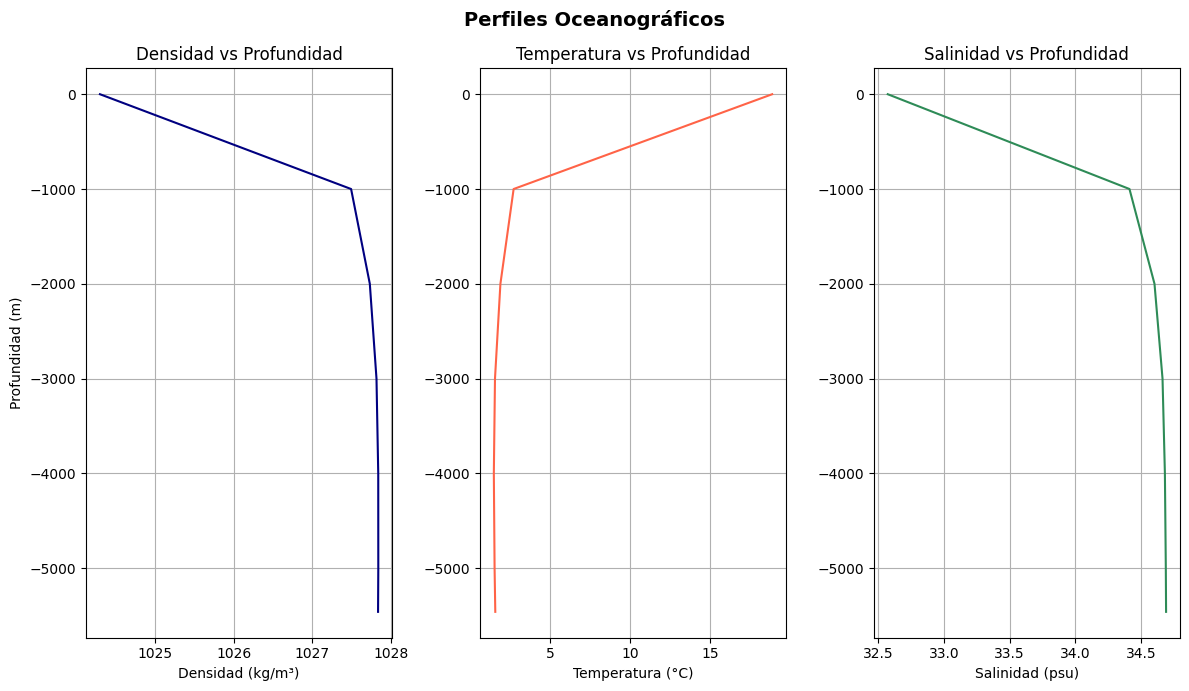

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 7))

# Densidad
axes[0].plot(ρ, -z, color='navy')
axes[0].set_xlabel('Densidad (kg/m³)')
axes[0].set_ylabel('Profundidad (m)')
axes[0].set_title('Densidad vs Profundidad')
axes[0].grid(True)

# Temperatura
axes[1].plot(T, -z, color='tomato')
axes[1].set_xlabel('Temperatura (°C)')
axes[1].set_title('Temperatura vs Profundidad')
axes[1].grid(True)

# Salinidad
axes[2].plot(S, -z, color='seagreen')
axes[2].set_xlabel('Salinidad (psu)')
axes[2].set_title('Salinidad vs Profundidad')
axes[2].grid(True)

plt.suptitle('Perfiles Oceanográficos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## b) Perfil de temperatura potencial

In [26]:
import numpy as np

# defino gradiente adiabático por partes usando condiciones booleanas (°C/m)
Γ = np.where(z <= 1000, 0,
    np.where(z <= 5000, 0.14e-3,
                        0.19e-3))
θ = T + Γ * z

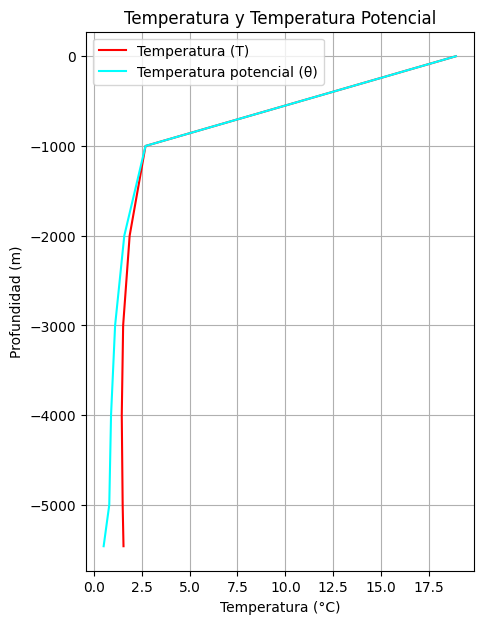

In [31]:
plt.figure(figsize=(5, 7))

plt.plot(T, -z, color='red', label='Temperatura (T)')
plt.plot(θ, -z, color='cyan', label='Temperatura potencial (θ)')

plt.xlabel('Temperatura (°C)')
plt.ylabel('Profundidad (m)')
plt.title('Temperatura y Temperatura Potencial')
plt.legend()
plt.grid(True)
plt.show()